In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as  plt
%matplotlib inline

In [52]:
df_index  = pd.read_csv("Economic_index.csv")

In [53]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [54]:
## drop unnecessary columns
df_index.drop(columns=["Unnamed: 0","year","month"],inplace = True)

In [55]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [56]:
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

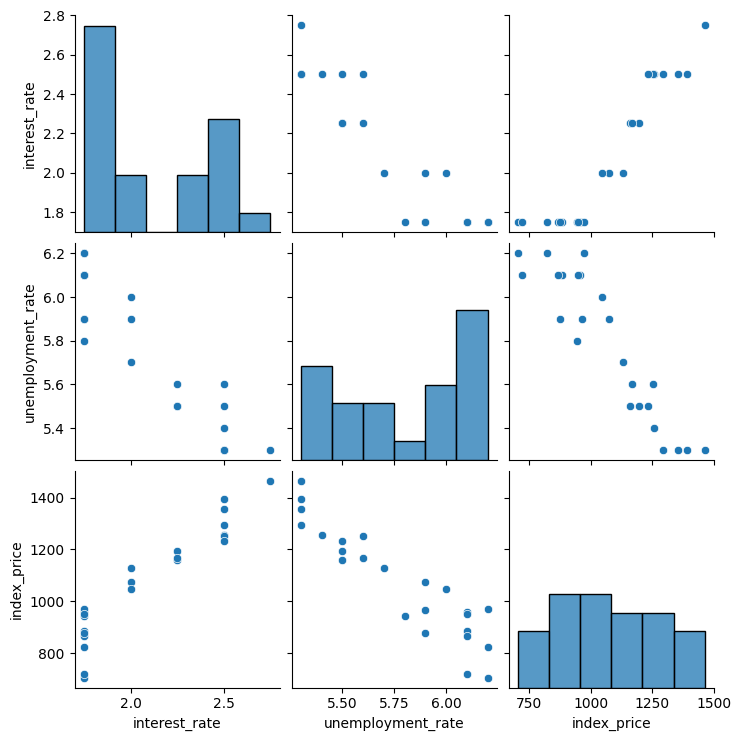

In [57]:
## let's do some visualization
import seaborn as sns
sns.pairplot(df_index)

In [58]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'unemployment rate')

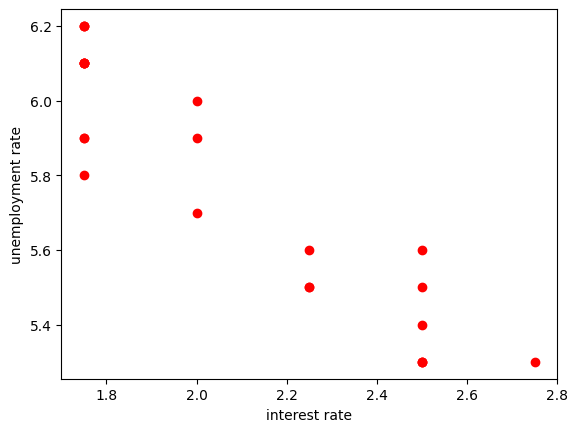

In [59]:
## visulise the data points more closely
plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'],color='r')
plt.xlabel("interest rate")
plt.ylabel("unemployment rate")

In [60]:
## independent and dependent features
X = df_index.iloc[:,:-1]
y = df_index.iloc[:,-1]

In [61]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [62]:
y

0     1464
1     1394
2     1357
3     1293
4     1256
5     1254
6     1234
7     1195
8     1159
9     1167
10    1130
11    1075
12    1047
13     965
14     943
15     958
16     971
17     949
18     884
19     866
20     876
21     822
22     704
23     719
Name: index_price, dtype: int64

In [63]:
#  train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.25,random_state=42)

In [64]:
import seaborn as sns

In [93]:
# sns.regplot():
# - Used in EDA to visualize the relationship between two numerical variables.
# - Creates a scatter plot and fits a regression line.
# - Helps check whether a linear relationship exists between feature and target.
#
# X-axis:
#   -> Independent variable / Feature
#
# Y-axis:
#   -> Dependent variable / Target
#
# Regression line represents:
#       y = mx + c
#
# where:
#   m = slope (effect of x on y)
#   c = intercept
#
# If points are close to the line:
#   -> Strong linear relationship
#
# If points are widely scattered:
#   -> Weak/no linear relationship
#
# Code:
#
# import seaborn as sns
#
# sns.regplot(
#     x='feature_column',
#     y='target_column',
#     data=df
# )

<Axes: xlabel='interest_rate', ylabel='index_price'>

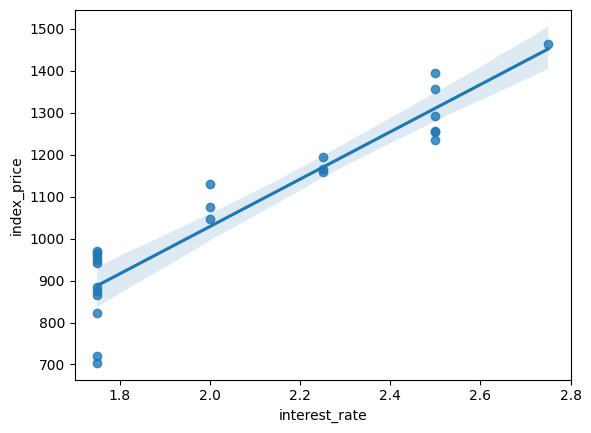

In [65]:
sns.regplot(
    x='interest_rate',
    y='index_price',
    data=df_index
)

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

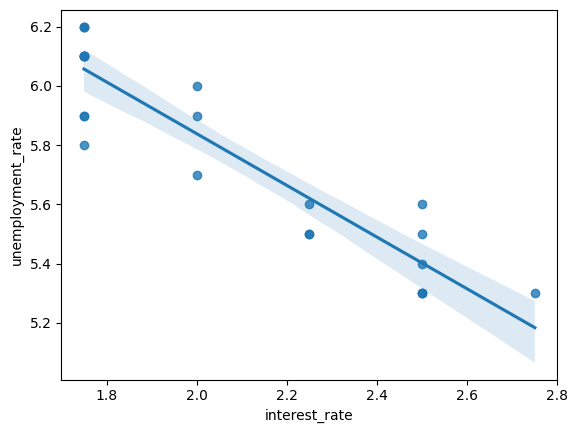

In [66]:
sns.regplot(
    x='interest_rate',
    y='unemployment_rate',
    data=df_index
)

In [67]:
from sklearn.preprocessing import StandardScaler


In [68]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [69]:
X_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [70]:
X_test

array([[ 0.57346234, -0.8615569 ],
       [-0.90115511,  1.30956648],
       [ 2.0480798 , -1.48187786],
       [-0.90115511,  0.999406  ],
       [-0.16384638,  0.37908503],
       [ 0.57346234, -0.55139641]])

In [71]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

In [72]:
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
## cross validation
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(regression,X_train,y_train,scoring="neg_mean_squared_error",cv=3)

In [94]:
# Cross Validation:
# - Technique used to evaluate how well a model performs on unseen data.
# - Instead of using only one train-test split, data is divided into multiple parts (folds).
#
# K-Fold Cross Validation:
# - Dataset is divided into K equal parts/folds.
# - Model is trained K times.
# - In each iteration:
#       -> K-1 folds are used for training
#       -> 1 fold is used for testing/validation
# - Every fold gets a chance to become the test data once.
#
# Example (5-Fold CV):
# Iteration 1: Train(Fold 2,3,4,5) Test(Fold 1)
# Iteration 2: Train(Fold 1,3,4,5) Test(Fold 2)
# ...
# Final Score = Average of all validation scores
#
# Advantages:
# - Gives more reliable model performance
# - Reduces dependency on random train-test split
# - Helps detect overfitting and underfitting
#
# Important:
# - Use cross validation only on training data during model selection.
# - Keep final test data untouched for final evaluation.
#
# Code:
#
# from sklearn.model_selection import cross_val_score
#
# model = LinearRegression()
#
# scores = cross_val_score(
#     model,
#     X_train,
#     y_train,
#     cv=5
# )
#
# print(scores)        # Scores from each fold
# print(scores.mean()) # Average CV score

In [75]:
np.mean(validation_score)


np.float64(-5914.828180162386)

In [77]:
## prediction
y_pred = regression.predict(X_test)
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [79]:
## performnace metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [80]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

5793.762887712569
59.935781523235484
76.11677139574805


In [81]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
print(score)

0.8278978091457145


In [82]:
## display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1] - 1)


0.7131630152428576

## assumptions 

In [95]:
# Linear Regression Assumptions:
#
# 1. Linearity:
# - Features and target should have linear relationship.
# - Check using scatterplot/regplot.
#
# 2. No Multicollinearity:
# - Independent variables should not be highly correlated.
# - Check using correlation matrix or VIF.
#
# 3. Normality of Residuals:
# - Prediction errors should follow normal distribution.
# - residual = actual - predicted
# - Check using KDE plot / histogram.
#
# 4. Homoscedasticity:
# - Residuals should have constant variance.
# - Check residual vs predicted plot.
#
# 5. No Autocorrelation:
# - Residuals should be independent.
# - Check using Durbin-Watson test.

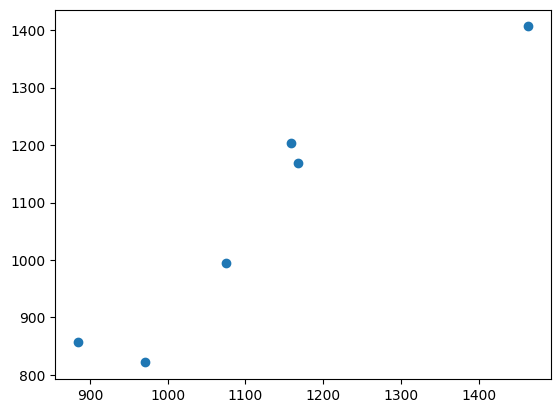

In [83]:
plt.scatter(y_test,y_pred)

In [84]:
residuals = y_test - y_pred
print(residuals)

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64


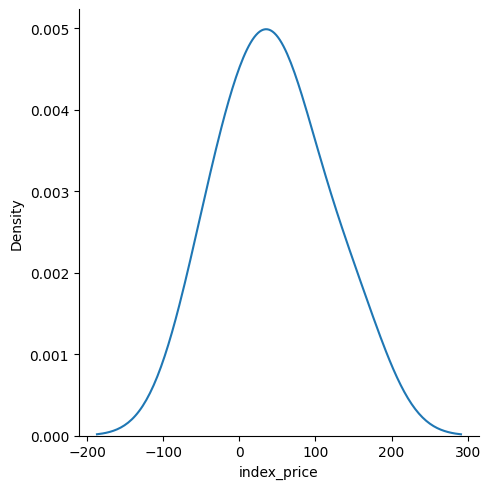

In [87]:
## plot this residuals
sns.displot(residuals,kind='kde')

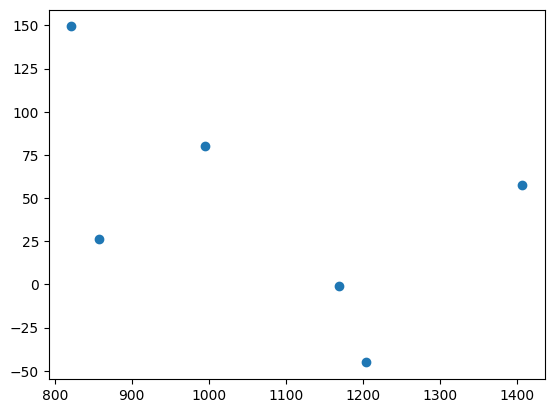

In [88]:
## scatter  plot wrt predictions and residuals
plt.scatter(y_pred,residuals)

In [89]:
## OlS linear Regression
!pip install statsmodels
import statsmodels.api as sm


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [90]:
model = sm.OLS(y_train,X_train).fit()

In [91]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Sun, 05 Jul 2026   Prob (F-statistic):                       0.754
Time:                        01:47:36   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [92]:
print(regression.coef_)

[  88.27275507 -116.25716066]
